# Imports

In [1]:
import warnings
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

from dstoolkit.automl.regressor import AutoMLLightGBM, AutoMLLightGBMCV

/home/junior/Documentos/GitHub/data-science-toolkit/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore")

## Functions

In [3]:
def generate_synthetic_regression_data(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    noise=0.2,
    test_size=0.2,
    valid_size=0.2,
    random_state=42
):
    """
    Gera dados sintéticos para problemas de regressão.
    
    Parâmetros
    ----------
    n_samples : int
        Número total de observações a serem geradas.
    n_features : int
        Número total de variáveis preditoras.
    n_informative : int
        Número de variáveis realmente informativas (as outras serão ruído).
    noise : float
        Nível de ruído adicionado à variável resposta.
    test_size : float
        Proporção da base reservada para teste.
    valid_size : float
        Proporção da base de treino reservada para validação.
    random_state : int
        Semente para reprodutibilidade.
    
    Retorna
    -------
    X_train, y_train, X_valid, y_valid, X_test, y_test : pd.DataFrame
        Bases de treino, validação e teste.
    """

    X, y = make_regression(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        noise=noise,
        random_state=random_state
    )

    # Cria DataFrames nomeados
    feature_names = [f"feature_{i}" for i in range(n_features)]
    X = pd.DataFrame(X, columns=feature_names)
    y = pd.DataFrame(y, columns=["target"])

    # Divide em treino/teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Divide parte de treino em treino/validação
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train, y_train, test_size=valid_size, random_state=random_state
    )

    return X_train, y_train, X_valid, y_valid, X_test, y_test

## Data Base

In [4]:
X_train, y_train, X_valid, y_valid, X_test, y_test = generate_synthetic_regression_data(
    n_samples=5000,
    n_features=20,
    n_informative=8,
    noise=5.0
)

# Regressor

## LightGBM

In [5]:
lgbm = AutoMLLightGBM(target='target', scoring='mean_absolute_error', tune=True, n_trials=20, random_state=42)
lgbm.train(X_train, y_train, X_valid, y_valid, X_test, y_test)

In [6]:
lgbm.get_metrics()

,R2,MAE,MadAE,MAPE,RMSE,Explained Variance
Train,0.999409,2.587688,2.011037,0.098411,3.600288,0.999409
Valid,0.979871,14.174196,10.815023,0.432730,20.673982,0.979895
Test,0.982121,14.669492,11.377523,0.612281,19.825360,0.982189


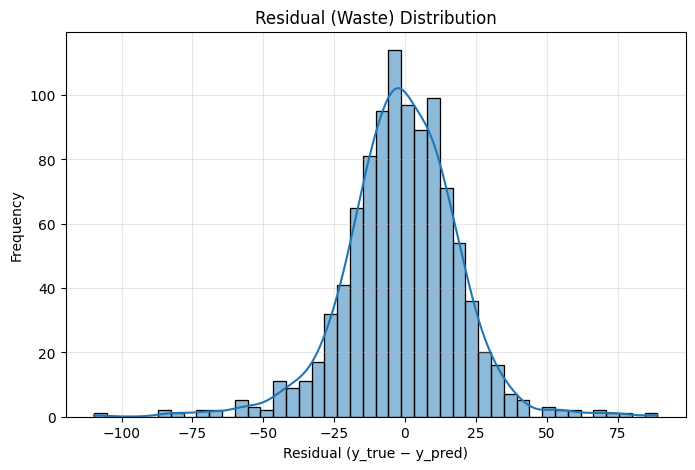

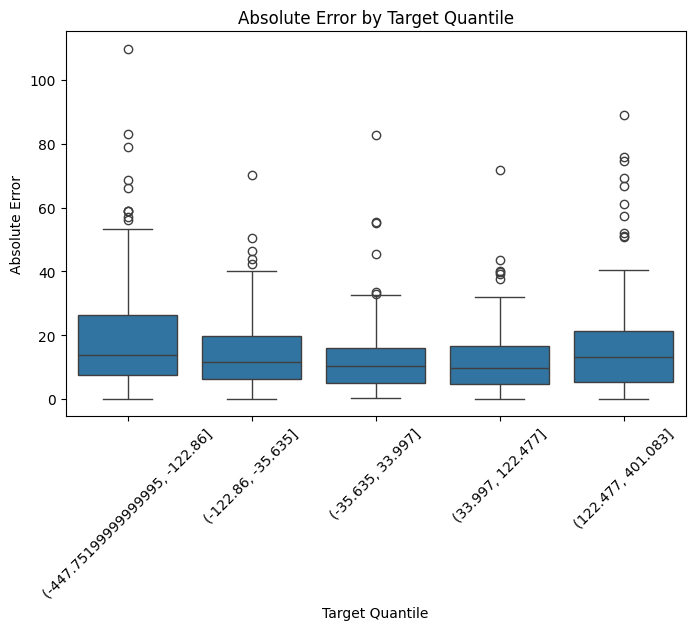

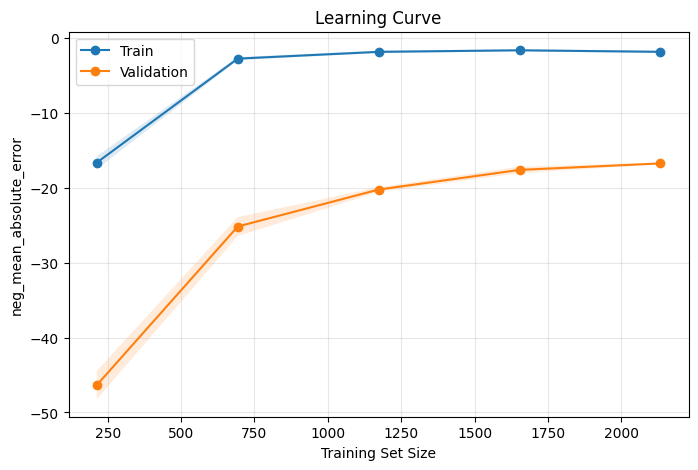

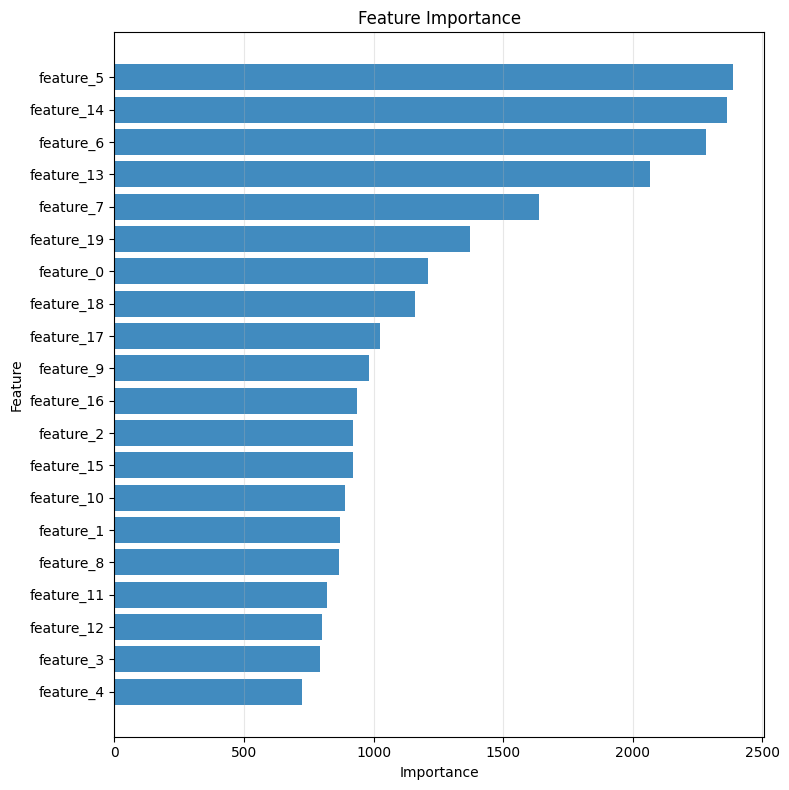

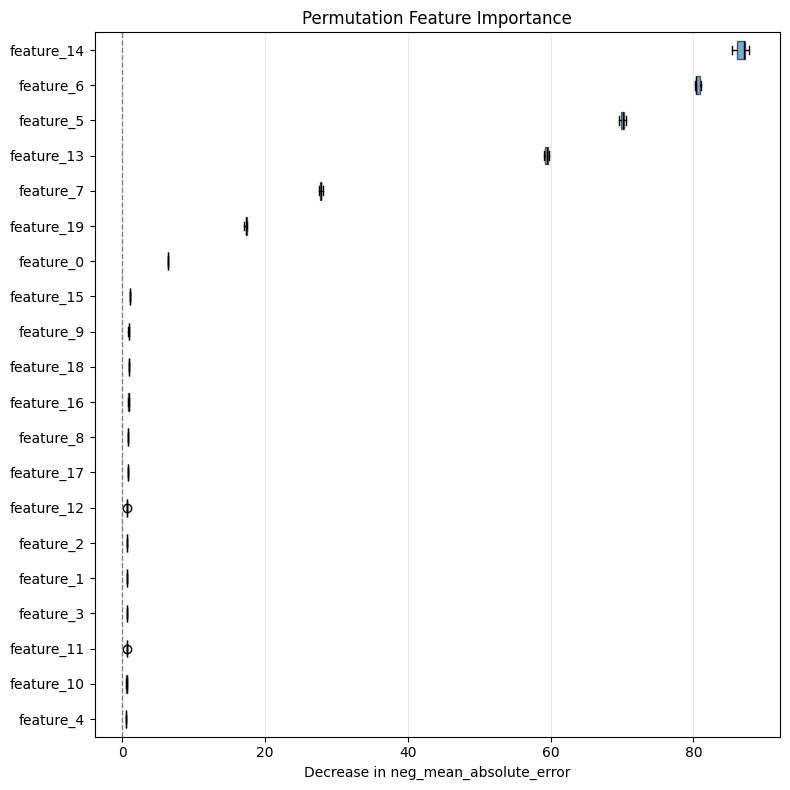

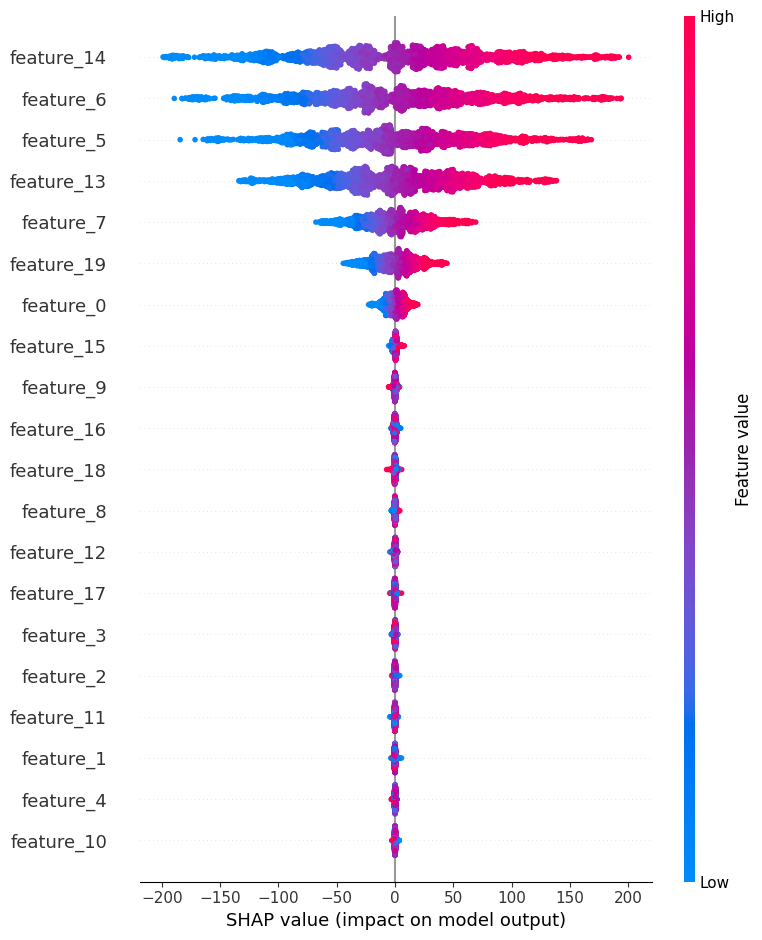

In [7]:
lgbm.analyze()

## LightGBM CV

In [8]:
lgbm_cv = AutoMLLightGBMCV(target='target', scoring='mean_absolute_percentage_error', tune=True, random_state=42)
lgbm_cv.train(X_train, y_train, X_test, y_test)

In [9]:
lgbm_cv.get_metrics()

,R2,MAE,MadAE,MAPE,RMSE,Explained Variance
Train CV,0.971963,17.599944,12.951106,0.558082,24.752954,0.971967
Test,0.975244,16.977123,12.650431,0.805824,23.328838,0.975354


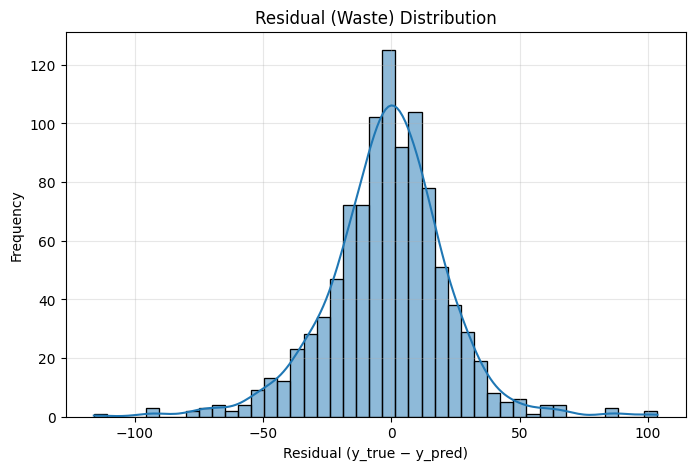

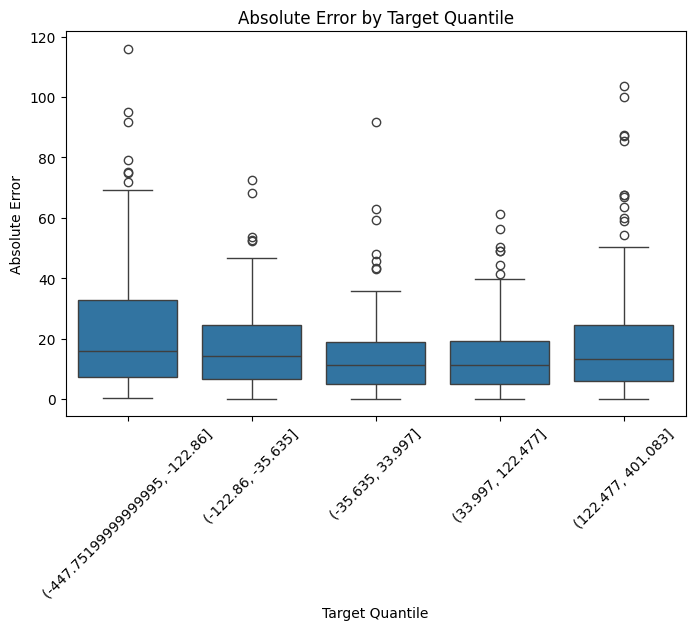

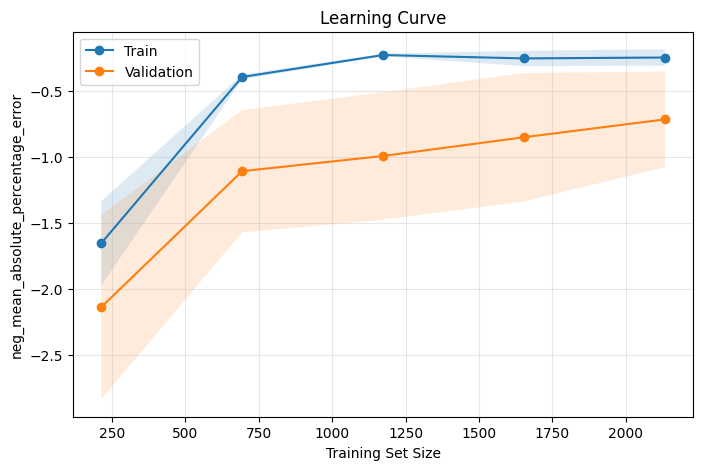

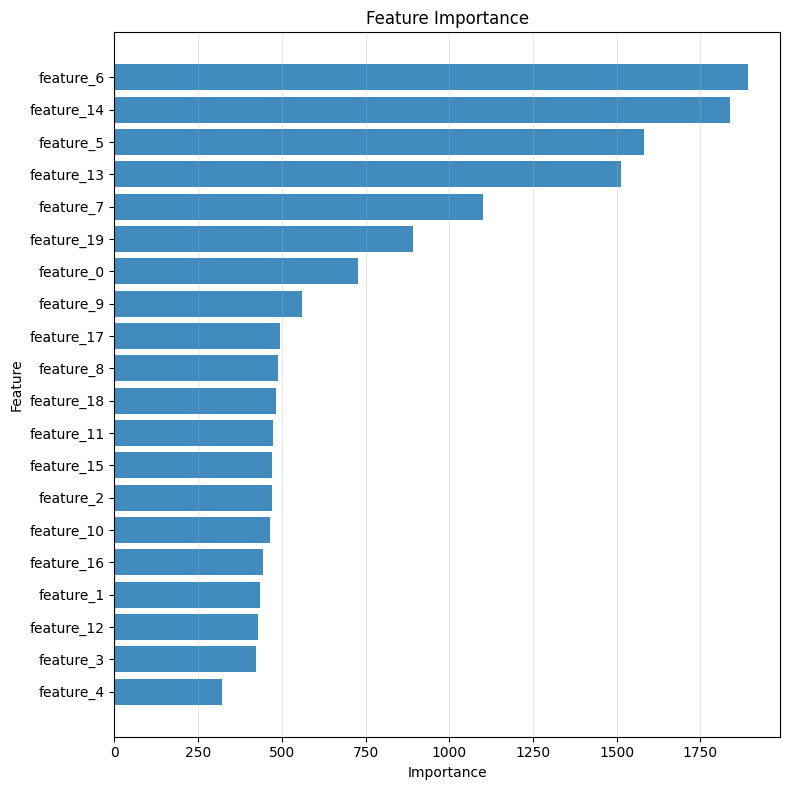

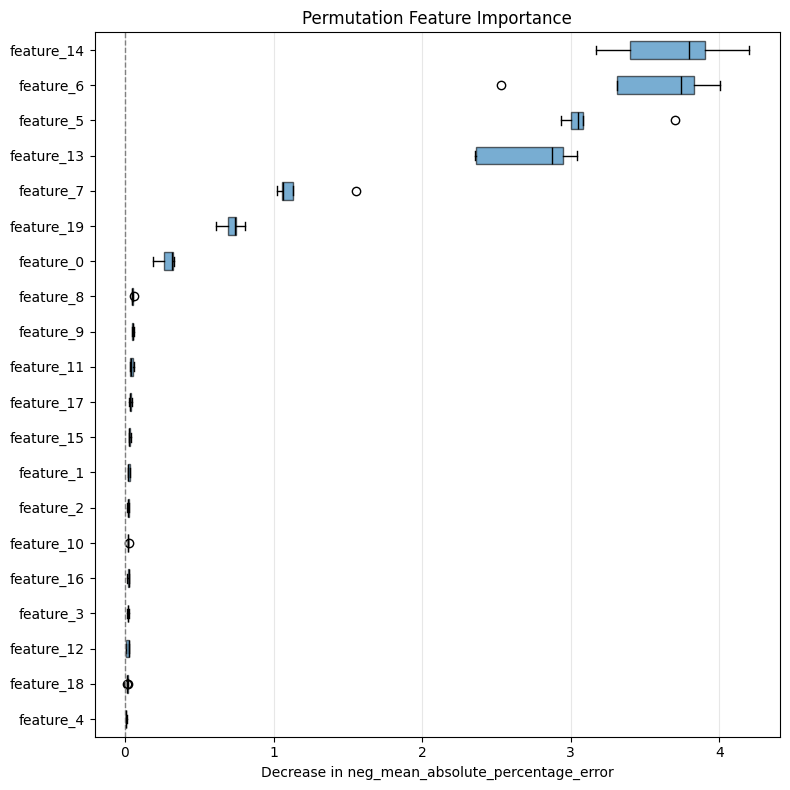

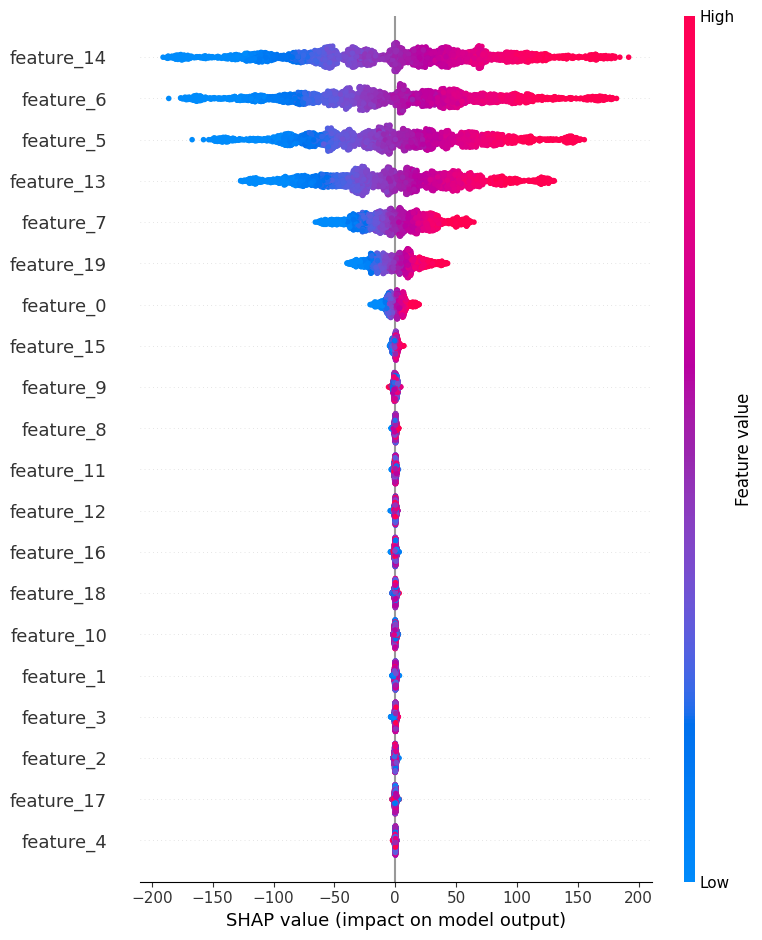

In [10]:
lgbm_cv.analyze()